First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Dataset Shape:
(891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


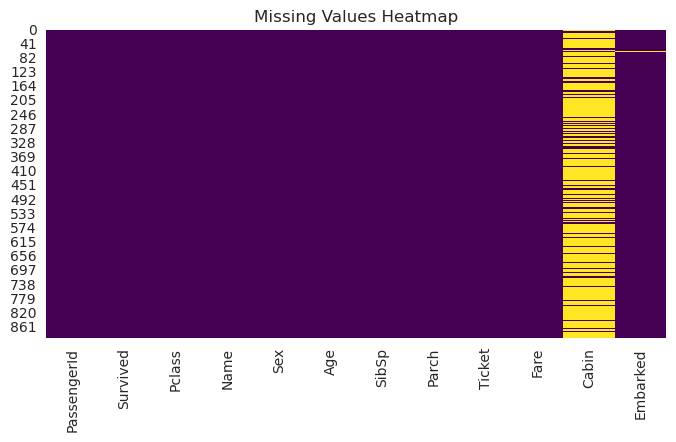

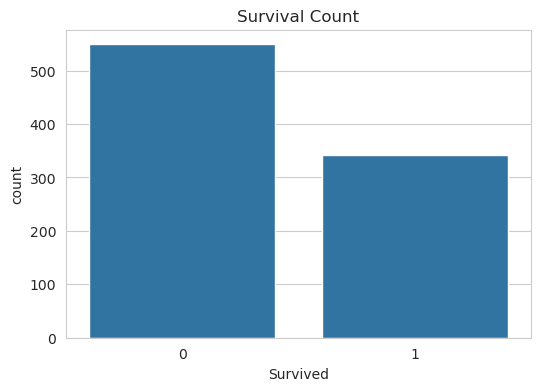

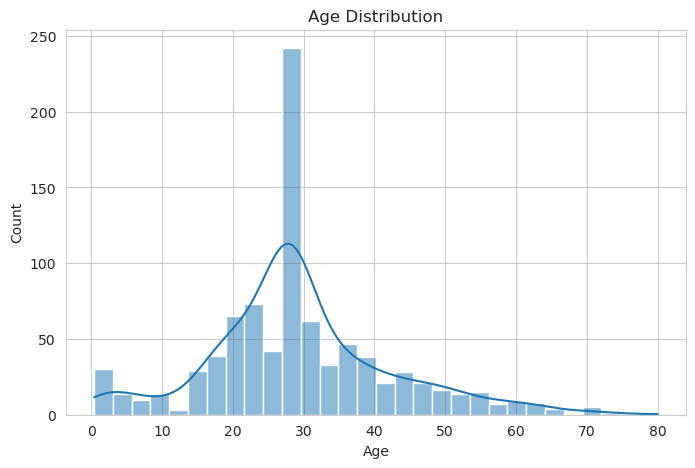

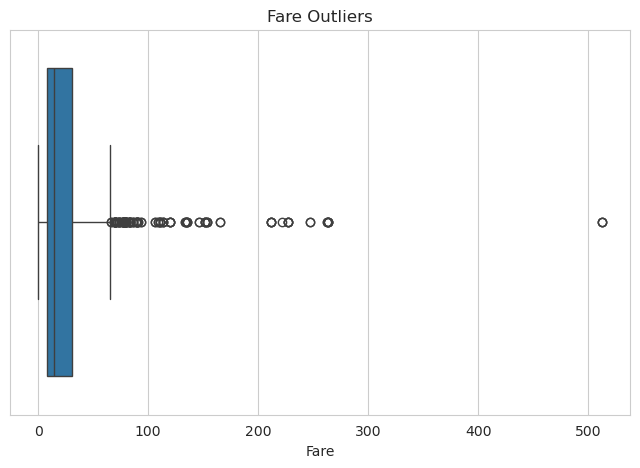

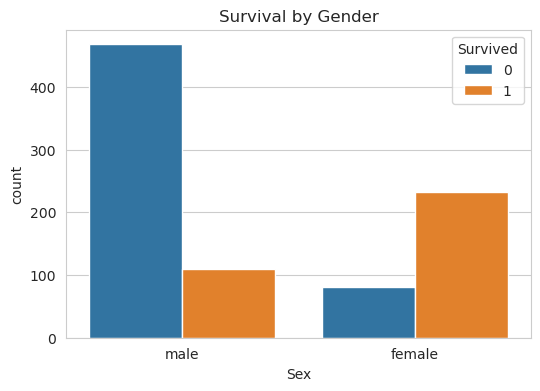

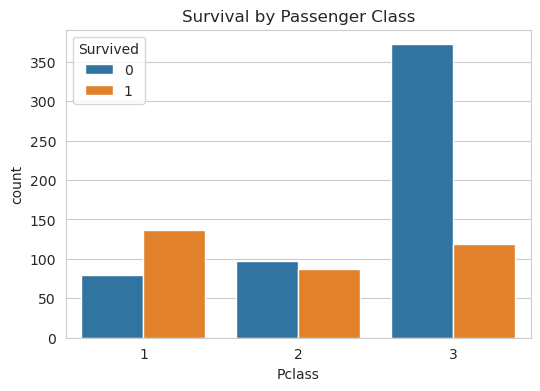

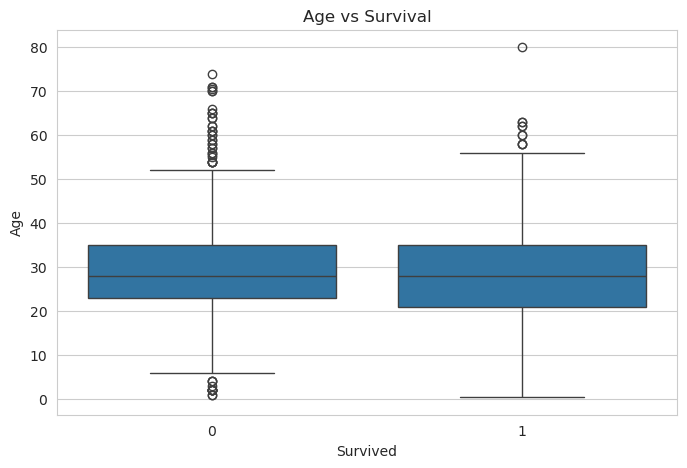

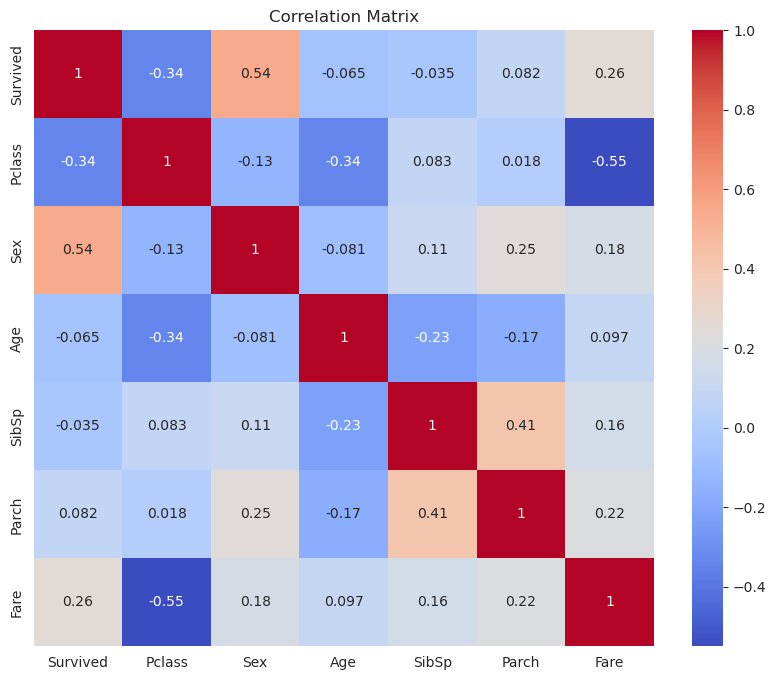

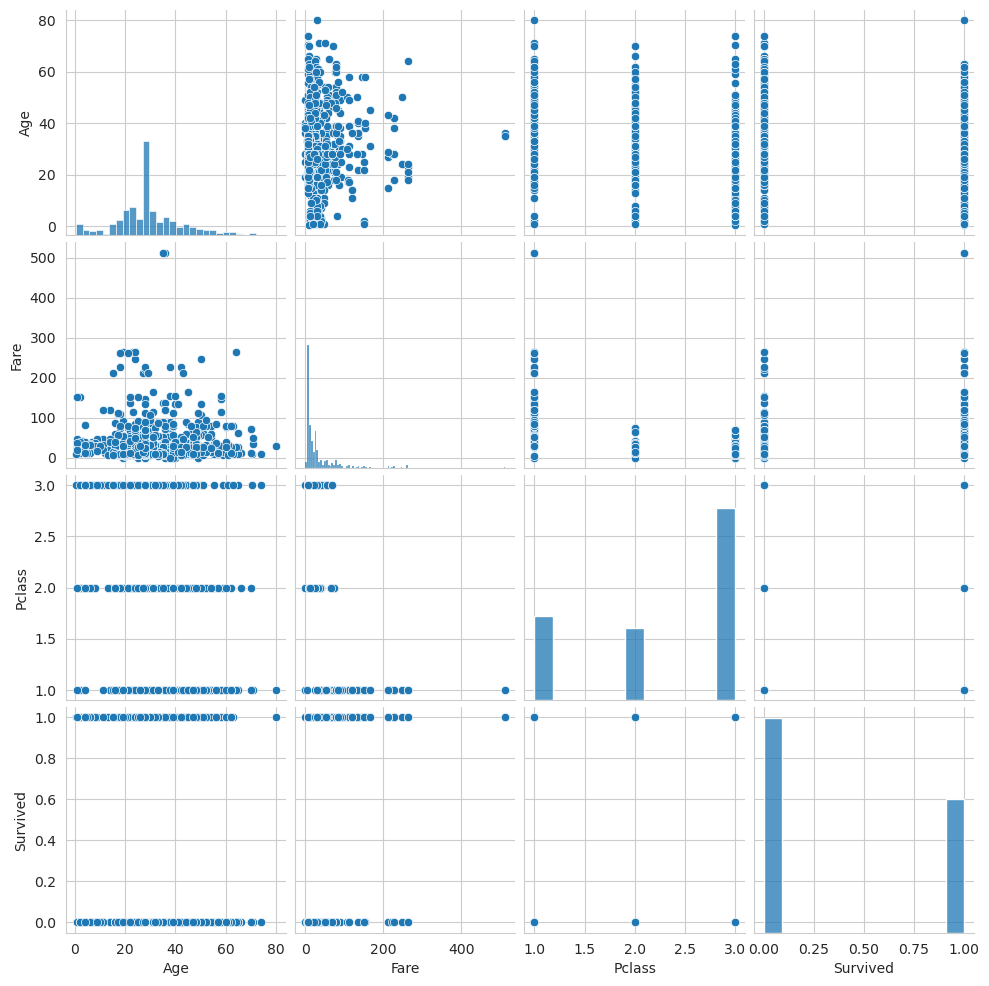

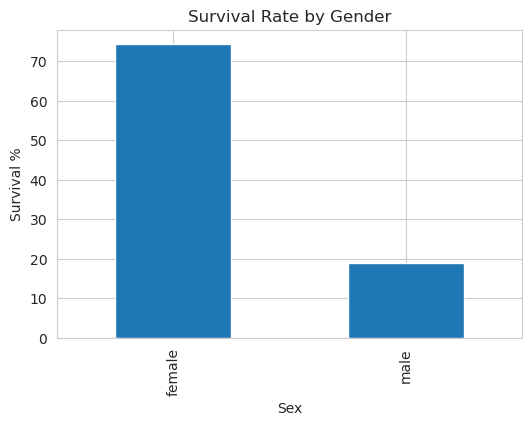

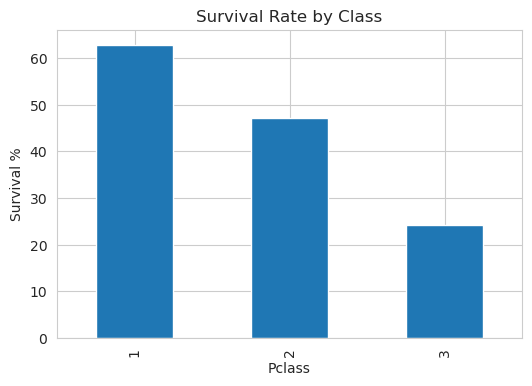

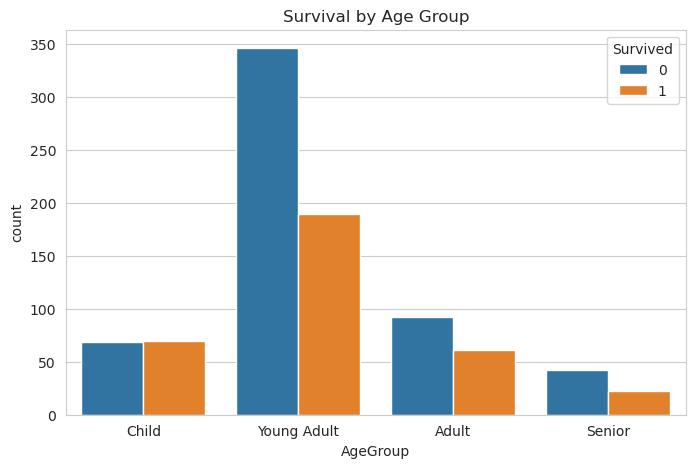

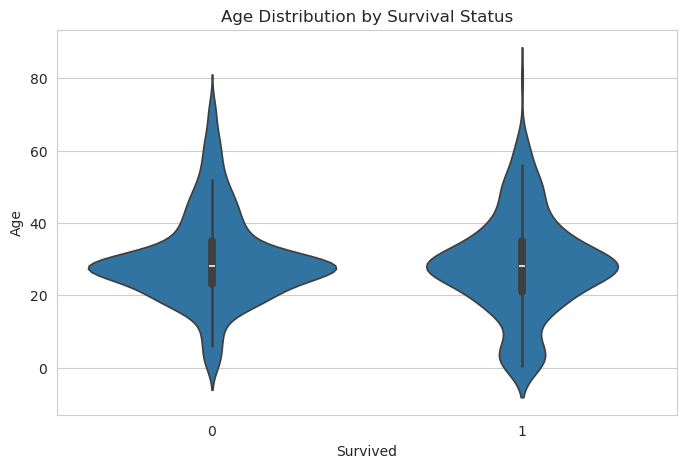

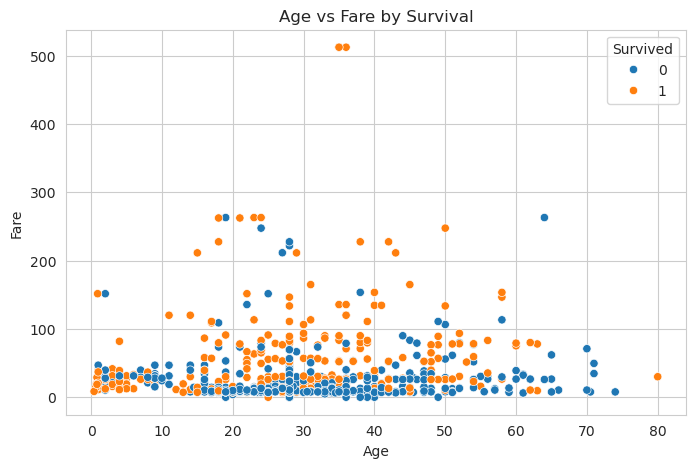


Survival Rate by Gender (%)
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Passenger Class (%)
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
1. Female survival rate: 74.20%
2. Male survival rate: 18.89%
3. First class survival rate: 62.96%
4. Third class survival rate: 24.24%
5. Age and Fare show moderate relationship with survival


In [7]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 2. Load Dataset
df = pd.read_csv("train.csv")

print("First 5 Rows:")
display(df.head())

# 3. Data Overview
print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

# 4. Data Cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())

# Missing Values Heatmap
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# 5. Univariate Analysis

# Survival Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Fare Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

# 6. Bivariate Analysis

# Survival vs Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival vs Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age vs Survival
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

# 7. Correlation Analysis

df2 = df.copy()

df2['Sex'] = df2['Sex'].map({
    'male': 0,
    'female': 1
})

corr = df2[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 8. Feature Relationships

sns.pairplot(
    df[['Age', 'Fare', 'Pclass', 'Survived']]
)
plt.show()

# 9. Additional Analysis

# Survival Rate by Gender
survival_rate = df.groupby('Sex')['Survived'].mean() * 100

plt.figure(figsize=(6,4))
survival_rate.plot(kind='bar')
plt.ylabel("Survival %")
plt.title("Survival Rate by Gender")
plt.show()

# Survival Rate by Class
survival_class = df.groupby('Pclass')['Survived'].mean() * 100

plt.figure(figsize=(6,4))
survival_class.plot(kind='bar')
plt.ylabel("Survival %")
plt.title("Survival Rate by Class")
plt.show()

# Age Group Analysis
bins = [0, 18, 35, 50, 100]
labels = ['Child', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(8,5))
sns.countplot(
    x='AgeGroup',
    hue='Survived',
    data=df
)
plt.title("Survival by Age Group")
plt.show()

# Extra Visualization 1
plt.figure(figsize=(8,5))
sns.violinplot(
    x='Survived',
    y='Age',
    data=df
)
plt.title("Age Distribution by Survival Status")
plt.show()

# Extra Visualization 2
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Age',
    y='Fare',
    hue='Survived',
    data=df
)
plt.title("Age vs Fare by Survival")
plt.show()

# Key Metrics
print("\nSurvival Rate by Gender (%)")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\nSurvival Rate by Passenger Class (%)")
print(df.groupby('Pclass')['Survived'].mean() * 100)

# Top 5 Findings
findings = [
    "Female survival rate: 74.20%",
    "Male survival rate: 18.89%",
    "First class survival rate: 62.96%",
    "Third class survival rate: 24.24%",
    "Age and Fare show moderate relationship with survival"
]

for i, finding in enumerate(findings, start=1):
    print(f"{i}. {finding}")

In [2]:
import os

print(os.getcwd())


/home/rguktrkvalley/Task5


In [3]:
import os

print(os.listdir())

['train.csv', 'anaconda3', 'test.csv', 'Task5.ipynb', 'gender_submission.csv', '.ipynb_checkpoints']
